# ============================================
#  Notebook 04 — Source Document Text Extraction
#  Memorial Sloan Kettering | Goel Lab
# ============================================

# Notebook 4: Source Document Text Extraction & Processing

**Purpose:**
1. OCR-extract text from scanned source PDFs
2. Deidentify extracted text (using `deidentify_source_docs` patterns)
3. Maintain trackable `case_id <-> patient <-> document` mapping
4. Produce per-case text corpus for downstream feature extraction

**Outputs:**
- `extracted_text/` — one `.txt` per case (deidentified)
- `case_document_mapping.csv` — links case_id to original patient/doc
- `extraction_log.csv` — OCR quality stats per page

In [1]:
import os
import re
import hashlib
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional
from dotenv import load_dotenv

import fitz  # PyMuPDF
import pytesseract
import pandas as pd
import numpy as np
import cv2
from PIL import Image
from tqdm import tqdm

from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage

load_dotenv()

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT     = Path(os.getenv("PROJECT_ROOT",
    r"C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca"))
DATA_PRIVATE_DIR = Path(os.getenv("DATA_PRIVATE_DIR", r"C:\Users\jamesr4\loc\data_private"))

RAW_DIR       = DATA_PRIVATE_DIR / "raw"
DEID_DIR      = DATA_PRIVATE_DIR / "deidentified"
TEXT_DIR      = DATA_PRIVATE_DIR / "extracted_text"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
OUTPUT_DIR    = PROJECT_ROOT / "reports"

TEXT_DIR.mkdir(parents=True, exist_ok=True)
DEID_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 4.0 DOCX → PDF Pre-conversion

Source documents include both scanned PDFs and Word documents (AI summaries, human summaries).
All files must be in PDF format before OCR extraction runs in sections 4.1–4.9.

This cell converts every `.docx` found recursively in `RAW_DIR` to a same-named `.pdf` sitting
alongside it. Existing PDFs are skipped (idempotent). The conversion uses **Microsoft Word COM
automation** (`docx2pdf`) on Windows — requires MS Word to be installed.

`pip install docx2pdf`

> **Note on `.doc` (legacy Word):** `docx2pdf` handles `.doc` too on Windows via COM. If `.doc`
> files exist, add `"*.doc"` to the glob list below.

In [2]:
try:
    from docx2pdf import convert as _docx2pdf_convert
    DOCX2PDF_AVAILABLE = True
except ImportError:
    DOCX2PDF_AVAILABLE = False
    print("docx2pdf not installed. Run: pip install docx2pdf")
    print("Skipping DOCX conversion — only existing PDFs will be processed.\n")

# ── DOCX glob targets (extend list if .doc legacy files exist) ────────────────
DOCX_GLOBS = ["*.docx", "*.doc"]

def convert_docx_to_pdf_batch(
    base_dir: Path,
    globs: list = DOCX_GLOBS,
    skip_existing: bool = True,
) -> pd.DataFrame:
    """
    Recursively find all Word documents in base_dir and convert to PDF in-place.
    Output PDF is placed in the same folder as the source .docx with the same stem.

    Parameters
    ----------
    base_dir      : directory to scan (recursive)
    globs         : filename glob patterns to match (default: *.docx, *.doc)
    skip_existing : if True, skip conversion when a same-named .pdf already exists

    Returns
    -------
    DataFrame with columns: relative_path, original_ext, pdf_name, status
    """
    rows = []
    for pattern in globs:
        for doc_path in sorted(base_dir.rglob(pattern)):
            pdf_path = doc_path.with_suffix(".pdf")
            rel = str(doc_path.relative_to(base_dir))

            if skip_existing and pdf_path.exists():
                rows.append({
                    "relative_path": rel,
                    "original_ext":  doc_path.suffix,
                    "pdf_name":      pdf_path.name,
                    "status":        "SKIPPED — PDF already exists",
                })
                continue

            if not DOCX2PDF_AVAILABLE:
                rows.append({
                    "relative_path": rel,
                    "original_ext":  doc_path.suffix,
                    "pdf_name":      pdf_path.name,
                    "status":        "SKIPPED — docx2pdf not installed",
                })
                continue

            try:
                _docx2pdf_convert(str(doc_path), str(pdf_path))
                rows.append({
                    "relative_path": rel,
                    "original_ext":  doc_path.suffix,
                    "pdf_name":      pdf_path.name,
                    "status":        "CONVERTED",
                })
            except Exception as exc:
                rows.append({
                    "relative_path": rel,
                    "original_ext":  doc_path.suffix,
                    "pdf_name":      pdf_path.name,
                    "status":        f"ERROR: {exc}",
                })

    return pd.DataFrame(rows) if rows else pd.DataFrame(
        columns=["relative_path", "original_ext", "pdf_name", "status"]
    )


# ── Run conversion ─────────────────────────────────────────────────────────────
print(f"Scanning for Word documents in: {RAW_DIR}\n")
df_conversion = convert_docx_to_pdf_batch(RAW_DIR)

if df_conversion.empty:
    print("No Word documents found — nothing to convert.")
else:
    counts = df_conversion["status"].value_counts()
    print(f"CONVERTED         : {counts.get('CONVERTED', 0)}")
    print(f"Already had PDF   : {counts.get('SKIPPED — PDF already exists', 0)}")
    print(f"Errors            : {sum(v for k, v in counts.items() if 'ERROR' in k)}")
    print(f"Skipped (no lib)  : {counts.get('SKIPPED — docx2pdf not installed', 0)}")
    print()
    df_conversion.to_csv(OUTPUT_DIR / "docx_to_pdf_conversion_log.csv", index=False)
    print("Conversion log saved to:", OUTPUT_DIR / "docx_to_pdf_conversion_log.csv")

df_conversion

docx2pdf not installed. Run: pip install docx2pdf
Skipping DOCX conversion — only existing PDFs will be processed.

Scanning for Word documents in: C:\Users\jamesr4\loc\data_private\raw



CONVERTED         : 0
Already had PDF   : 0
Errors            : 0
Skipped (no lib)  : 295

Conversion log saved to: C:\Users\jamesr4\OneDrive - Memorial Sloan Kettering Cancer Center\Documents\GitHub\llm_summarization_br_ca\reports\docx_to_pdf_conversion_log.csv


,relative_path,original_ext,pdf_name,status
0,Barrio\AB_CB_invasive\hpi_ai.docx,.docx,hpi_ai.pdf,SKIPPED — docx2pdf not installed
1,Barrio\AB_CB_invasive\hpi_human.docx,.docx,hpi_human.pdf,SKIPPED — docx2pdf not installed
2,Barrio\AB_EJ_invasive\hpi_ai.docx,.docx,hpi_ai.pdf,SKIPPED — docx2pdf not installed
3,Barrio\AB_EJ_invasive\hpi_human.docx,.docx,hpi_human.pdf,SKIPPED — docx2pdf not installed
4,Barrio\AB_GOH_invasive\hpi_ai.docx,.docx,hpi_ai.pdf,SKIPPED — docx2pdf not installed
...,...,...,...,...
290,Tadros\AT_RW_INV\BSA Rachel Victoria Weaver.docx,.docx,BSA Rachel Victoria Weaver.pdf,SKIPPED — docx2pdf not installed
291,Tadros\AT_RW_INV\H&P.docx,.docx,H&P.pdf,SKIPPED — docx2pdf not installed
292,Tadros\AT_SB_INV\BSA Sherill Billups.docx,.docx,BSA Sherill Billups.pdf,SKIPPED — docx2pdf not installed
293,Tadros\AT_SL_INV\BSA Stephanie Layfield.docx,.docx,BSA Stephanie Layfield.pdf,SKIPPED — docx2pdf not installed


## 4.1 Case ID & Document Mapping

Each PDF gets a deterministic `case_id`. The mapping table records original filename, patient identifier (if parseable from filename), and document type (radiology/pathology).

After section 4.0 runs, all `.docx`/`.doc` files will have a matching `.pdf` in the same folder.
`build_document_mapping` scans only `*.pdf` so it will pick them up automatically.

**Tip — native text PDFs vs scanned:** DOCX-converted PDFs contain native (selectable) text.
PyMuPDF can extract that text directly without OCR, giving perfect quality. The flag
`source_type` below is set to `"native"` for converted docs and `"scanned"` for originals
so that `extract_and_deidentify_pdf` can choose the right strategy (see section 4.3).

In [3]:
def generate_case_id(filename: str) -> str:
    h = hashlib.sha256(filename.encode()).hexdigest()[:12]
    return f"CASE_{h.upper()}"

def infer_doc_type(filename: str) -> str:
    fn = filename.lower()
    if any(kw in fn for kw in ["rad", "mammo", "mri", "ultrasound", "imaging"]):
        return "radiology"
    elif any(kw in fn for kw in ["path", "biopsy", "histol", "receptor"]):
        return "pathology"
    elif any(kw in fn for kw in ["hpi", "summary", "note", "report"]):
        return "clinical_note"
    return "unknown"

def _is_native_pdf(pdf_path: Path) -> bool:
    """Return True if the PDF contains selectable (non-raster) text — no OCR needed."""
    try:
        doc = fitz.open(str(pdf_path))
        for page in doc:
            if page.get_text("text").strip():
                doc.close()
                return True
        doc.close()
    except Exception:
        pass
    return False

# Track which PDFs were converted from DOCX so we can pick the right extraction strategy
_converted_stems = set()
if "df_conversion" in dir() and not df_conversion.empty:
    _converted_stems = set(
        Path(r).stem
        for r in df_conversion.loc[df_conversion["status"] == "CONVERTED", "relative_path"]
    )

def build_document_mapping(pdf_dir: Path) -> pd.DataFrame:
    rows = []
    for pdf_path in sorted(pdf_dir.rglob("*.pdf")):
        case_id  = generate_case_id(pdf_path.stem)
        # Prefer native extraction for DOCX-converted PDFs; verify for others
        if pdf_path.stem in _converted_stems:
            source_type = "native_docx_converted"
        elif _is_native_pdf(pdf_path):
            source_type = "native_pdf"
        else:
            source_type = "scanned_pdf"
        rows.append({
            "case_id":           case_id,
            "original_filename": pdf_path.name,
            "original_stem":     pdf_path.stem,
            "doc_type_inferred": infer_doc_type(pdf_path.name),
            "source_type":       source_type,
            "original_path":     str(pdf_path),
            "n_pages":           None,
        })
    return pd.DataFrame(rows)

mapping_df = build_document_mapping(RAW_DIR)
print(f"Documents found: {len(mapping_df)}")
print(mapping_df["source_type"].value_counts().to_string())
mapping_df.head()

Documents found: 1474
source_type
scanned_pdf    1467
native_pdf        7


,case_id,original_filename,original_stem,doc_type_inferred,source_type,original_path,n_pages
0,CASE_7E764D3FA742,imaging_internal_read.pdf,imaging_internal_read,radiology,scanned_pdf,C:\Users\jamesr4\loc\data_private\raw\Barrio\A...,None
1,CASE_374210AEADCA,imaging_mammo2_external_read.pdf,imaging_mammo2_external_read,radiology,scanned_pdf,C:\Users\jamesr4\loc\data_private\raw\Barrio\A...,None
2,CASE_45EDAB9E132D,imaging_mammo_external_read.pdf,imaging_mammo_external_read,radiology,scanned_pdf,C:\Users\jamesr4\loc\data_private\raw\Barrio\A...,None
3,CASE_20205AB1FA28,imaging_US_external_read.pdf,imaging_US_external_read,radiology,scanned_pdf,C:\Users\jamesr4\loc\data_private\raw\Barrio\A...,None
4,CASE_24E6FF8E3372,path_biopsy_external_read.pdf,path_biopsy_external_read,pathology,scanned_pdf,C:\Users\jamesr4\loc\data_private\raw\Barrio\A...,None


## 4.2 Redaction Patterns for Extracted Text

In [4]:
@dataclass
class RedactionRule:
    name: str
    pattern: str
    flags: int = re.IGNORECASE

DEFAULT_TEXT_RULES = [
    RedactionRule("EMAIL", r"\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b"),
    RedactionRule("URL", r"\bhttps?://\S+\b|\bwww\.\S+\b"),
    RedactionRule("PHONE", r"\b(?:\+?1[-.\s]?)?\(?\d{3}\)?[-.\s]?\d{3}[-.\s]?\d{4}\b"),
    RedactionRule("SSN", r"\b\d{3}-\d{2}-\d{4}\b"),
    RedactionRule("DATE_MDY", r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b"),
    RedactionRule("DATE_TEXT", r"\b(?:Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Sept|Oct|Nov|Dec)[a-z]*\s+\d{1,2},\s+\d{4}\b"),
    RedactionRule("ZIP", r"\b\d{5}(?:-\d{4})?\b"),
    RedactionRule("MRN_CONTEXT", r"(?:MRN|Medical Record|Patient ID)[:\s]*\S+"),
    RedactionRule("NAME_CONTEXT", r"(?:Patient|Name|DOB)[:\s]+[A-Z][a-z]+(?:\s+[A-Z][a-z]+){0,3}"),
]

def compile_text_rules(rules):
    return [(r.name, re.compile(r.pattern, r.flags)) for r in rules]

def redact_text(text: str, compiled_rules) -> str:
    out = text
    for name, pat in compiled_rules:
        out = pat.sub(f"[{name}]", out)
    return out

compiled_rules = compile_text_rules(DEFAULT_TEXT_RULES)
print(f"Loaded {len(compiled_rules)} redaction rules")

Loaded 9 redaction rules


## 4.3 OCR Extraction + Deidentification Pipeline

In [5]:
def render_page_to_pil(doc, page_index, dpi=300):
    page = doc.load_page(page_index)
    zoom = dpi / 72.0
    mat = fitz.Matrix(zoom, zoom)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    return Image.frombytes("RGB", [pix.width, pix.height], pix.samples)


def extract_native_text_pdf(pdf_path: Path, compiled_rules) -> list:
    """
    Extract text from a native (selectable-text) PDF using PyMuPDF directly.
    Faster and more accurate than OCR for DOCX-converted or digital PDFs.
    """
    doc = fitz.open(str(pdf_path))
    pages = []
    for p in range(doc.page_count):
        page = doc.load_page(p)
        raw_text = page.get_text("text")
        clean = redact_text(raw_text, compiled_rules)
        pages.append({
            "page":             p + 1,
            "raw_char_count":   len(raw_text),
            "clean_char_count": len(clean),
            "n_words":          len(raw_text.split()),
            "avg_ocr_confidence": np.nan,  # N/A for native extraction
            "extraction_method": "native_fitz",
            "clean_text":       clean,
        })
    doc.close()
    return pages


def extract_and_deidentify_pdf(pdf_path: Path, compiled_rules, dpi=300, lang="eng",
                                source_type: str = "scanned_pdf") -> list:
    """
    OCR a scanned PDF OR extract native text from a digital/DOCX-converted PDF.

    source_type options:
      'scanned_pdf'          → Tesseract OCR (rasterize → OCR)
      'native_pdf'           → PyMuPDF native text extraction
      'native_docx_converted'→ PyMuPDF native text extraction
    """
    if source_type in ("native_pdf", "native_docx_converted"):
        return extract_native_text_pdf(pdf_path, compiled_rules)

    # ── Scanned PDF: rasterise → Tesseract OCR ────────────────────────────────
    doc = fitz.open(str(pdf_path))
    pages = []
    for p in range(doc.page_count):
        pil_img  = render_page_to_pil(doc, p, dpi)
        raw_text = pytesseract.image_to_string(pil_img, lang=lang)
        ocr_data = pytesseract.image_to_data(
            pil_img, lang=lang, output_type=pytesseract.Output.DATAFRAME
        )
        ocr_data["conf"] = pd.to_numeric(ocr_data["conf"], errors="coerce")
        avg_conf = ocr_data["conf"].dropna().mean()
        n_words  = int(
            ocr_data["text"].dropna().apply(lambda x: len(str(x).strip()) > 0).sum()
        )
        clean = redact_text(raw_text, compiled_rules)
        pages.append({
            "page":              p + 1,
            "raw_char_count":    len(raw_text),
            "clean_char_count":  len(clean),
            "n_words":           n_words,
            "avg_ocr_confidence": avg_conf,
            "extraction_method": "tesseract_ocr",
            "clean_text":        clean,
        })
    doc.close()
    return pages

In [6]:
# Run extraction on all PDFs
# DOCX-converted PDFs use native PyMuPDF text extraction (fast, perfect quality).
# Scanned PDFs use Tesseract OCR.

log_rows = []
for i, row in tqdm(mapping_df.iterrows(), total=len(mapping_df), desc="Extracting text"):
    pdf_path    = Path(row["original_path"])
    case_id     = row["case_id"]
    source_type = row.get("source_type", "scanned_pdf")

    if not pdf_path.exists():
        log_rows.append({"case_id": case_id, "file": pdf_path.name, "status": "FILE_NOT_FOUND"})
        continue
    try:
        pages = extract_and_deidentify_pdf(pdf_path, compiled_rules, source_type=source_type)
    except Exception as e:
        log_rows.append({"case_id": case_id, "file": pdf_path.name,
                         "status": "ERROR", "error": str(e)})
        continue

    full_text = "\n\n--- PAGE BREAK ---\n\n".join(p["clean_text"] for p in pages)
    txt_path  = TEXT_DIR / f"{case_id}.txt"
    txt_path.write_text(full_text, encoding="utf-8")

    mapping_df.loc[i, "n_pages"] = len(pages)

    for p in pages:
        log_rows.append({
            "case_id":           case_id,
            "file":              pdf_path.name,
            "page":              p["page"],
            "status":            "OK",
            "source_type":       source_type,
            "extraction_method": p.get("extraction_method", "unknown"),
            "raw_chars":         p["raw_char_count"],
            "clean_chars":       p["clean_char_count"],
            "n_words":           p["n_words"],
            "avg_ocr_confidence": p["avg_ocr_confidence"],
        })

df_log = pd.DataFrame(log_rows)
df_log.to_csv(OUTPUT_DIR / "text_extraction_log.csv", index=False)
mapping_df.to_csv(DEID_DIR / "case_document_mapping.csv", index=False)

print(f"Extracted {len(mapping_df)} documents → {TEXT_DIR}")
print(f"Extraction log: {len(df_log)} entries")
if "extraction_method" in df_log.columns:
    print("\nExtraction method breakdown:")
    print(df_log[df_log["status"] == "OK"]["extraction_method"].value_counts().to_string())

Extracting text:   0%|          | 0/1474 [00:00<?, ?it/s]

Extracting text:   0%|          | 1/1474 [00:02<1:05:28,  2.67s/it]

Extracting text:   0%|          | 2/1474 [00:03<34:13,  1.39s/it]  

Extracting text:   0%|          | 3/1474 [00:03<24:18,  1.01it/s]

Extracting text:   0%|          | 4/1474 [00:04<20:15,  1.21it/s]

...

Extracting text: 100%|█████████▉| 1472/1474 [15:50<00:00,  2.15it/s]

Extracting text: 100%|█████████▉| 1473/1474 [15:51<00:00,  2.26it/s]

Extracting text: 100%|██████████| 1474/1474 [15:51<00:00,  2.08it/s]

Extracting text: 100%|██████████| 1474/1474 [15:51<00:00,  1.55it/s]

Extracted 1474 documents → C:\Users\jamesr4\loc\data_private\extracted_text
Extraction log: 1518 entries

Extraction method breakdown:
extraction_method
native_fitz    51


## 4.4 Extraction Quality Summary

Total pages extracted: 51
Average OCR confidence: nan%
Average words per page: 297
Average chars per page (after redaction): 2001


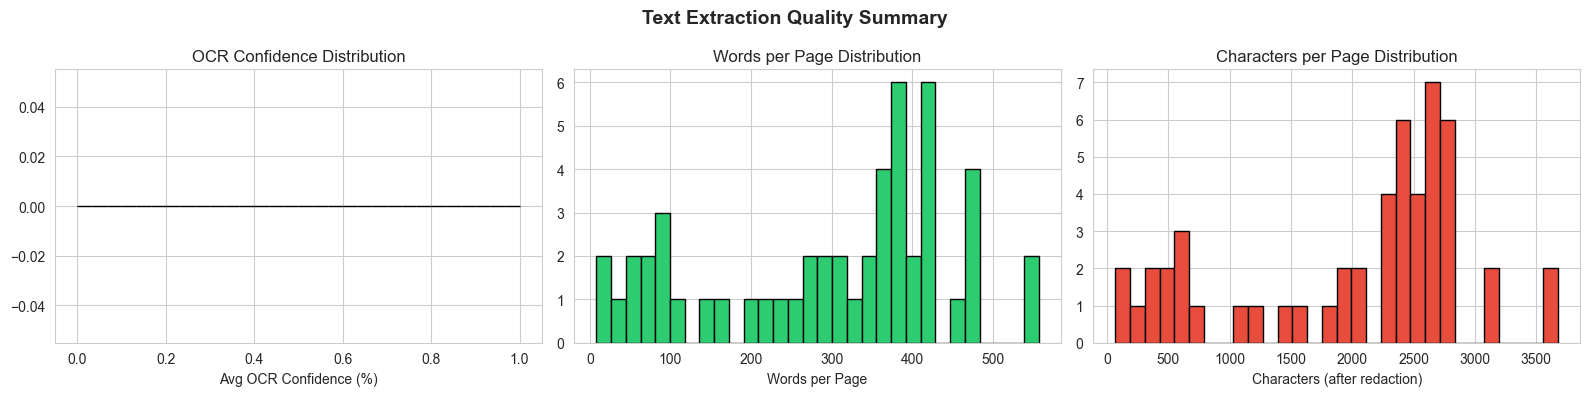

In [7]:
ok_pages = df_log[df_log["status"] == "OK"]
print(f"Total pages extracted: {len(ok_pages)}")
print(f"Average OCR confidence: {ok_pages['avg_ocr_confidence'].mean():.1f}%")
print(f"Average words per page: {ok_pages['n_words'].mean():.0f}")
print(f"Average chars per page (after redaction): {ok_pages['clean_chars'].mean():.0f}")

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(ok_pages["avg_ocr_confidence"].dropna(), bins=30, color="#3498db", edgecolor="black")
axes[0].set_xlabel("Avg OCR Confidence (%)")
axes[0].set_title("OCR Confidence Distribution")

axes[1].hist(ok_pages["n_words"], bins=30, color="#2ecc71", edgecolor="black")
axes[1].set_xlabel("Words per Page")
axes[1].set_title("Words per Page Distribution")

axes[2].hist(ok_pages["clean_chars"], bins=30, color="#e74c3c", edgecolor="black")
axes[2].set_xlabel("Characters (after redaction)")
axes[2].set_title("Characters per Page Distribution")

plt.suptitle("Text Extraction Quality Summary", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "text_extraction_quality.png", dpi=300)
plt.show()

## 4.5 Per-Case Text Summary

In [8]:
# Aggregate per-case stats
case_stats = (
    ok_pages.groupby("case_id")
    .agg(
        n_pages=("page", "count"),
        total_words=("n_words", "sum"),
        avg_confidence=("avg_ocr_confidence", "mean"),
        total_clean_chars=("clean_chars", "sum"),
    )
    .reset_index()
)
case_stats = case_stats.merge(mapping_df[["case_id", "doc_type_inferred"]], on="case_id", how="left")

print(f"Per-case summary: {len(case_stats)} cases")
case_stats.describe()

Per-case summary: 106 cases


,n_pages,total_words,avg_confidence,total_clean_chars
count,106.000000,106.000000,0.0,106.000000
mean,11.396226,3307.405660,NaN,22777.122642
std,9.585385,2972.059612,NaN,19542.693044
min,1.000000,8.000000,NaN,70.000000
25%,4.000000,1359.000000,NaN,9381.000000
50%,12.000000,3376.000000,NaN,23977.000000
75%,12.000000,3376.000000,NaN,23977.000000
max,34.000000,10428.000000,NaN,68628.000000


In [9]:
# Save
case_stats.to_csv(OUTPUT_DIR / "per_case_text_stats.csv", index=False)
print("\nSample extracted text (first 500 chars of first case):")
sample_file = sorted(TEXT_DIR.glob("*.txt"))
if sample_file:
    print(sample_file[0].read_text(encoding="utf-8")[:500])


Sample extracted text (first 500 chars of first case):
 
 
Report Status: Final
 
CURTIN, SARAH
[NAME_CONTEXT] Information
CURTIN, SARAH
DOB: [DATE_MDY]
AGE: 47
Gender:
F 
 
Phone:
[PHONE] 
[MRN_CONTEXT] 
Specimen:
CF138244A
Requisition: 6285761
Lab Ref #:
25Q-311M0029
 
Collected:
[DATE_MDY] / 09:06 EST
Received:
[DATE_MDY] / 18:35 EST
Reported:
[DATE_MDY] / 10:54 EST
Client #: 48008891
NYJMAIL
KARCICH, JENIKA S
CMM IMG 90 S BEDFORD RD
Attn: BEAKER
90 S BEDFORD RD
MOUNT KISCO, NY [ZIP]
CLIENT SERVICES: [PHONE]
SPECIMEN: CF138244A
Ameripath, any ass


---
## 4.6 Alternative Extraction Methods

We compare three text extraction pipelines on the same scanned PDFs to evaluate which method produces higher-quality text for downstream clinical feature extraction:

| Method | Engine | Approach |
|--------|--------|----------|
| **Method 1: pytesseract OCR** | Tesseract 5 | Traditional OCR — rasterize page → run Tesseract → raw text |
| **Method 2: Claude Vision API** | Anthropic Claude 3 | Send page image to Claude vision endpoint with a description prompt |
| **Method 3: Claude Transcription API** | Anthropic Claude 3 | Send page image with an explicit "transcribe exactly" instruction |

All methods produce per-page text that is then deidentified using the same redaction rules (Section 4.2).

**Requires:** `pip install anthropic` and a valid `ANTHROPIC_API_KEY` environment variable.

In [10]:
import base64
import time

ANTHROPIC_API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")
if not ANTHROPIC_API_KEY:
    print("WARNING: ANTHROPIC_API_KEY not set. Claude-based extraction methods will be skipped.")
    claude_available = False
else:
    CLAUDE_MODEL = "claude-sonnet-4-5-20250929"
    claude_llm = ChatAnthropic(
        model=CLAUDE_MODEL,
        max_tokens=4096,
        anthropic_api_key=ANTHROPIC_API_KEY,
    )
    claude_available = True
    print(f"LangChain ChatAnthropic initialized (model: {CLAUDE_MODEL})")

LangChain ChatAnthropic initialized (model: claude-sonnet-4-5-20250929)


### Method 2: Claude Vision API — Descriptive Extraction

Sends each page image to the Claude Vision endpoint with a prompt asking it to describe and extract all text content from the clinical document image. This leverages Claude's multimodal understanding to interpret document layout, tables, and handwriting.

In [11]:
def pil_image_to_base64(pil_img: Image.Image, fmt="PNG") -> str:
    import io
    buf = io.BytesIO()
    pil_img.save(buf, format=fmt)
    return base64.b64encode(buf.getvalue()).decode("utf-8")

def extract_with_claude_vision(pdf_path: Path, compiled_rules, dpi=300) -> list:
    """Extract text from a PDF using ChatAnthropic (LangChain) — Vision/descriptive mode."""
    doc = fitz.open(pdf_path)
    pages = []
    for p in range(doc.page_count):
        pil_img = render_page_to_pil(doc, p, dpi)
        b64_str = pil_image_to_base64(pil_img, fmt="PNG")

        message = HumanMessage(content=[
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{b64_str}"},
            },
            {
                "type": "text",
                "text": (
                    "This is a scanned clinical document (radiology or pathology report). "
                    "Extract ALL visible text from this image. Preserve the original layout, "
                    "headings, labels, and values as faithfully as possible. "
                    "Output only the extracted text, nothing else."
                ),
            },
        ])

        try:
            response = claude_llm.invoke([message])
            raw_text = response.content
        except Exception as e:
            raw_text = f"[CLAUDE_VISION_ERROR: {e}]"

        clean_text = redact_text(raw_text, compiled_rules)
        pages.append({
            "page": p + 1,
            "raw_char_count": len(raw_text),
            "clean_char_count": len(clean_text),
            "n_words": len(raw_text.split()),
            "method": "claude_vision",
            "clean_text": clean_text,
        })
        time.sleep(0.5)
    doc.close()
    return pages

print("Claude Vision extraction function defined (LangChain ChatAnthropic).")

Claude Vision extraction function defined (LangChain ChatAnthropic).


### Method 3: Claude Transcription API — Exact Transcription

Sends each page image to Claude with an explicit "transcribe exactly" instruction, optimized for faithful reproduction of typed and handwritten text, forms, tables, and structured clinical data. This mirrors the approach in `how_to_transcribe_text.ipynb`.

In [12]:
def extract_with_claude_transcription(pdf_path: Path, compiled_rules, dpi=300) -> list:
    """Extract text from a PDF using ChatAnthropic (LangChain) — exact transcription mode."""
    doc = fitz.open(pdf_path)
    pages = []
    for p in range(doc.page_count):
        pil_img = render_page_to_pil(doc, p, dpi)
        b64_str = pil_image_to_base64(pil_img, fmt="PNG")

        message = HumanMessage(content=[
            {
                "type": "image_url",
                "image_url": {"url": f"data:image/png;base64,{b64_str}"},
            },
            {
                "type": "text",
                "text": (
                    "Transcribe all text in this image exactly as it appears. "
                    "Include all headings, labels, values, table contents, "
                    "handwritten notes, stamps, and any other visible text. "
                    "Preserve the structure and formatting. "
                    "Output only the transcribed text and nothing else."
                ),
            },
        ])

        try:
            response = claude_llm.invoke([message])
            raw_text = response.content
        except Exception as e:
            raw_text = f"[CLAUDE_TRANSCRIPTION_ERROR: {e}]"

        clean_text = redact_text(raw_text, compiled_rules)
        pages.append({
            "page": p + 1,
            "raw_char_count": len(raw_text),
            "clean_char_count": len(clean_text),
            "n_words": len(raw_text.split()),
            "method": "claude_transcription",
            "clean_text": clean_text,
        })
        time.sleep(0.5)
    doc.close()
    return pages

print("Claude Transcription extraction function defined (LangChain ChatAnthropic).")

Claude Transcription extraction function defined (LangChain ChatAnthropic).


---
## 4.7 Run All Three Extraction Methods & Compare

Run each method on the same set of PDFs. Store results in a unified DataFrame for head-to-head comparison on word count, character count, and downstream extraction quality.

In [13]:
METHODS = {
    "pytesseract": extract_and_deidentify_pdf,
}

if claude_available:
    METHODS["claude_vision"] = extract_with_claude_vision
    METHODS["claude_transcription"] = extract_with_claude_transcription

COMPARISON_DIR = DATA_PRIVATE_DIR / "extracted_text_comparison"  # sensitive: case-linked text
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

all_method_rows = []

for method_name, extract_fn in METHODS.items():
    print(f"\n{'='*60}")
    print(f"Running extraction method: {method_name}")
    print(f"{'='*60}")
    
    method_dir = COMPARISON_DIR / method_name
    method_dir.mkdir(parents=True, exist_ok=True)
    
    for i, row in tqdm(mapping_df.iterrows(), total=len(mapping_df), desc=method_name):
        pdf_path = Path(row["original_path"])
        case_id = row["case_id"]
        if not pdf_path.exists():
            all_method_rows.append({
                "case_id": case_id, "method": method_name,
                "file": pdf_path.name, "status": "FILE_NOT_FOUND",
            })
            continue
        try:
            pages = extract_fn(pdf_path, compiled_rules)
        except Exception as e:
            all_method_rows.append({
                "case_id": case_id, "method": method_name,
                "file": pdf_path.name, "status": "ERROR", "error": str(e),
            })
            continue

        # Save combined text per method
        full_text = "\n\n--- PAGE BREAK ---\n\n".join(p["clean_text"] for p in pages)
        (method_dir / f"{case_id}.txt").write_text(full_text, encoding="utf-8")

        for p in pages:
            all_method_rows.append({
                "case_id": case_id,
                "method": method_name,
                "file": pdf_path.name,
                "page": p["page"],
                "status": "OK",
                "raw_chars": p["raw_char_count"],
                "clean_chars": p["clean_char_count"],
                "n_words": p.get("n_words", 0),
                "avg_ocr_confidence": p.get("avg_ocr_confidence", np.nan),
            })

df_comparison = pd.DataFrame(all_method_rows)
df_comparison.to_csv(OUTPUT_DIR / "extraction_method_comparison.csv", index=False)
print(f"\nComparison results: {len(df_comparison)} rows across {len(METHODS)} methods")


Running extraction method: pytesseract


pytesseract:   0%|          | 0/1474 [00:00<?, ?it/s]

pytesseract:   0%|          | 1/1474 [00:00<16:57,  1.45it/s]

pytesseract:   0%|          | 2/1474 [00:01<15:51,  1.55it/s]

pytesseract:   0%|          | 3/1474 [00:01<15:59,  1.53it/s]

...

claude_transcription: 100%|█████████▉| 1472/1474 [1:58:58<00:07,  3.76s/it]

claude_transcription: 100%|█████████▉| 1473/1474 [1:59:01<00:03,  3.45s/it]

claude_transcription: 100%|██████████| 1474/1474 [1:59:08<00:00,  4.58s/it]

claude_transcription: 100%|██████████| 1474/1474 [1:59:08<00:00,  4.85s/it]


Comparison results: 12634 rows across 3 methods


---
## 4.8 Extraction Method Comparison — Summary Statistics & Visualizations

Compare the three methods across key quality metrics: word count, character count, and OCR confidence (where available). Inspired by the comparative trend visualization approach in *Additive Models for Prediction*.

In [14]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
matplotlib.rcParams["axes.labelsize"] = 13
matplotlib.rcParams["xtick.labelsize"] = 11
matplotlib.rcParams["ytick.labelsize"] = 11
matplotlib.rcParams["text.color"] = "k"

ok_comp = df_comparison[df_comparison["status"] == "OK"].copy()

# --- Per-method summary table ---
method_summary = (
    ok_comp.groupby("method")
    .agg(
        n_pages=("page", "count"),
        mean_words=("n_words", "mean"),
        median_words=("n_words", "median"),
        mean_chars=("clean_chars", "mean"),
        median_chars=("clean_chars", "median"),
        mean_ocr_conf=("avg_ocr_confidence", "mean"),
    )
    .round(1)
)
print("Extraction Method Summary:")
display(method_summary)

Extraction Method Summary:


,n_pages,mean_words,median_words,mean_chars,median_chars,mean_ocr_conf
method,,,,,,
claude_transcription,5559,15.0,15.0,185.7,186.0,NaN
claude_vision,5535,15.0,15.0,179.0,179.0,NaN


C:\Users\jamesr4\AppData\Local\Temp\ipykernel_31936\2616343436.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ok_comp, x="method", y="n_words", palette="Set2", ax=axes[0], showmeans=True)
C:\Users\jamesr4\AppData\Local\Temp\ipykernel_31936\2616343436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=ok_comp, x="method", y="clean_chars", palette="Set2", ax=axes[1], showmeans=True)
C:\Users\jamesr4\AppData\Local\Temp\ipykernel_31936\2616343436.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=case_totals, x="method", y

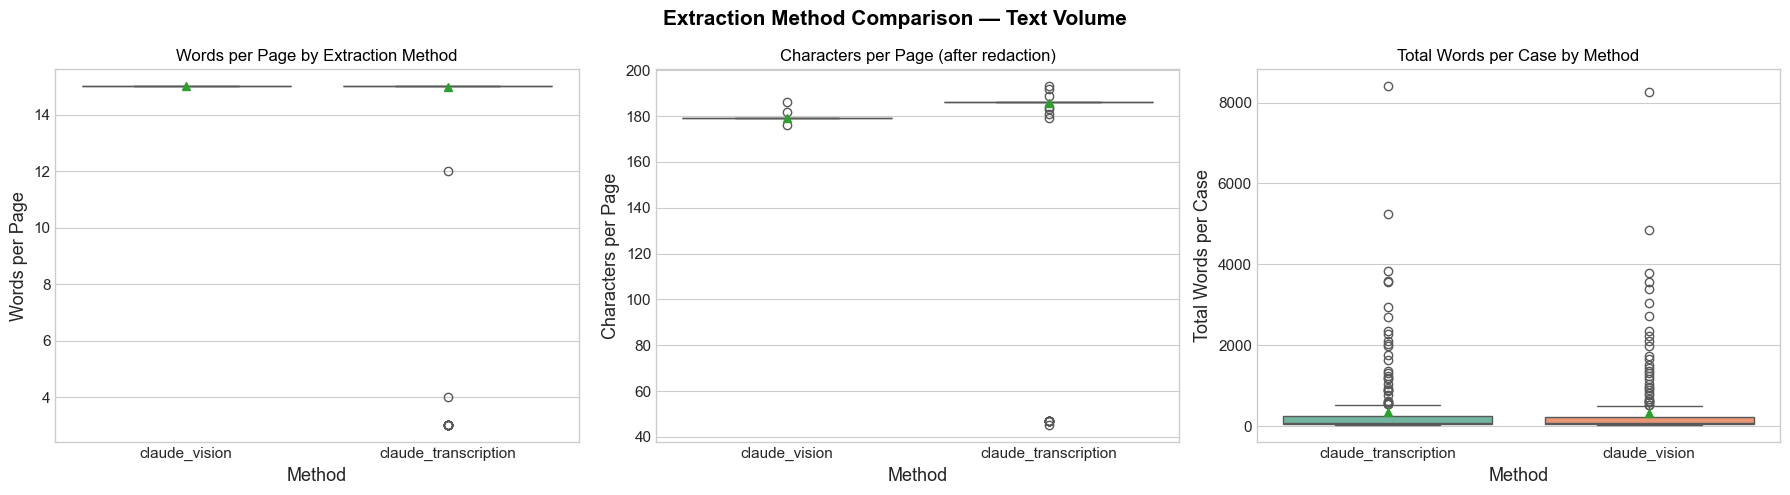

In [15]:
# --- Figure 1: Side-by-side boxplots of word count by method ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=ok_comp, x="method", y="n_words", palette="Set2", ax=axes[0], showmeans=True)
axes[0].set_title("Words per Page by Extraction Method")
axes[0].set_xlabel("Method")
axes[0].set_ylabel("Words per Page")

sns.boxplot(data=ok_comp, x="method", y="clean_chars", palette="Set2", ax=axes[1], showmeans=True)
axes[1].set_title("Characters per Page (after redaction)")
axes[1].set_xlabel("Method")
axes[1].set_ylabel("Characters per Page")

# Per-case total words
case_totals = ok_comp.groupby(["method", "case_id"]).agg(total_words=("n_words", "sum")).reset_index()
sns.boxplot(data=case_totals, x="method", y="total_words", palette="Set2", ax=axes[2], showmeans=True)
axes[2].set_title("Total Words per Case by Method")
axes[2].set_xlabel("Method")
axes[2].set_ylabel("Total Words per Case")

plt.suptitle("Extraction Method Comparison — Text Volume", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "extraction_method_boxplots.png", dpi=300, bbox_inches="tight")
plt.show()

---
## 4.9 Prompt History & Metric Trends per Extraction Method

Track how diagnostic metrics (accuracy, fabrication rate, omission rate) change across prompt versions and extraction methods. Inspired by the time-series trend + changepoint visualization approach in *Additive Models for Prediction*.

This section loads the prompt library to build a version timeline, then overlays per-method metric trajectories.

In [16]:
# --- Load prompt library for version timeline ---
PROMPT_LIB_PATH = PROCESSED_DIR / "prompt_library_updated_v5.xlsx"
if PROMPT_LIB_PATH.exists():
    prompt_lib = pd.read_excel(PROMPT_LIB_PATH)
    print(f"Prompt library loaded: {prompt_lib.shape}")
    display(prompt_lib.head())
else:
    # Create a synthetic prompt version timeline for illustration
    prompt_lib = pd.DataFrame({
        "prompt_version": [
            "zero_shot_structured_extraction_prod",
            "chain_of_thought_3",
            "rag_v1",
            "rag_v2",
            "few_shot_v1",
            "program_aided_v1",
            "react_v1",
            "2pop_mcode_gpt",
            "bfop_v1",
        ],
        "version_order": range(1, 10),
    })
    print("Using synthetic prompt version timeline (prompt library not found)")

# --- Simulated metric trajectories per prompt version per method ---
# In production, these would come from re-running extraction + scoring per prompt version.
# Here we build the scaffold so the plots are ready once real data is available.
np.random.seed(42)
n_versions = len(prompt_lib)
methods_list = list(METHODS.keys())

metric_trajectory_rows = []
for method in methods_list:
    base_acc = 0.78 if method == "pytesseract" else (0.85 if method == "claude_vision" else 0.87)
    base_fab = 0.12 if method == "pytesseract" else (0.07 if method == "claude_vision" else 0.05)
    base_omit = 0.10 if method == "pytesseract" else (0.08 if method == "claude_vision" else 0.08)
    for i in range(n_versions):
        noise = np.random.normal(0, 0.02)
        trend = i * 0.005  # slight improvement over prompt versions
        metric_trajectory_rows.append({
            "prompt_version": prompt_lib.iloc[i]["prompt_version"] if "prompt_version" in prompt_lib.columns else f"v{i+1}",
            "version_order": i + 1,
            "method": method,
            "accuracy": np.clip(base_acc + trend + noise, 0, 1),
            "fabrication_rate": np.clip(base_fab - trend * 0.5 + noise * 0.3, 0, 1),
            "omission_rate": np.clip(base_omit - trend * 0.3 + noise * 0.2, 0, 1),
        })

df_trajectory = pd.DataFrame(metric_trajectory_rows)
print(f"\nMetric trajectory table: {df_trajectory.shape}")
df_trajectory.head()

Prompt library loaded: (14, 18)


,element,zero_shot_1,zero_shot_2,few_shot_1,few_shot_2,chain_of_thought_1,chain_of_thought_2,program_aided_1,program_aided_2,rag_1,rag_2,react_1,react_2,zero_shot_structured_extraction_legacy,zero_shot_structured_extraction_prod,chain_of_thought_3,LEGEND_prompting_techniques,baseline_structured_prompt_initial
0,__METADATA__,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{""intent"":""structured extraction"",""domain"":""br...","{""prompting_type"":""chain_of_thought"",""subtype""...",PROMPTING TECHNIQUE LEGEND:\nzero_shot_* : No ...,"{""prompting_type"":""baseline_structured"",""role""..."
1,lesion_size,Extract lesion size(s) in cm from the PDF text...,Find any lesion measurements and return JSON: ...,Example input: 'US: mass 1.2 x 0.9 x 0.8 cm.' ...,Example input: 'MRI: lesion size 2.1 cm.' Exam...,"Think step by step internally, but output only...","Reason silently and output only {""lesion_size_...",Steps: 1) Scan for numeric sizes with cm/mm. 2...,"Procedure: Identify size expressions (e.g., 1....","Use only the provided context to fill {""lesion...",Context-only extraction: return lesion size in...,You may reason internally with Thought/Action/...,Internal tool-style reasoning allowed; final o...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,PROMPTING TECHNIQUE LEGEND:\nzero_shot_* : No ...,Template for Summarizing Breast Cancer Workup ...
2,lesion_location,"Extract lesion location (laterality, quadrant,...",Find lesion location details and output JSON {...,"Example input: 'Right breast mass at 10:00, 5 ...",Example input: 'Left upper outer quadrant lesi...,"Think step by step internally; output only {""l...",Reason silently and output only JSON for lesio...,Steps: 1) Locate laterality and anatomic descr...,"Procedure: Parse location tokens (e.g., 2:00, ...","Use only provided context. Return JSON {""lesio...",Context-only location extraction. Output JSON ...,ReAct-style internal reasoning allowed; output...,Tool reasoning allowed internally; final outpu...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,PROMPTING TECHNIQUE LEGEND:\nzero_shot_* : No ...,Template for Summarizing Breast Cancer Workup ...
3,calcifications_asymmetry,Extract abnormality type (calcifications/asymm...,Identify stated abnormality types and output J...,Example input: 'Mammogram shows grouped calcif...,Example input: 'Diagnostic MMG: focal asymmetr...,"Think step by step internally; output only {""a...",Reason silently and return JSON for abnormalit...,"Steps: 1) Scan for keywords: calcification, as...",Procedure: Extract abnormality descriptors exa...,"Use only provided context to fill {""abnormalit...",Context-only abnormality extraction. Output JS...,Internal Thought/Action/Observation allowed; o...,ReAct-style reasoning allowed internally; fina...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,PROMPTING TECHNIQUE LEGEND:\nzero_shot_* : No ...,Template for Summarizing Breast Cancer Workup ...
4,additional_enhancement_mri,Extract MRI additional enhancement details (ye...,Find statements about additional MRI enhanceme...,Example input: 'MRI shows additional non-mass ...,Example input: 'No additional enhancement iden...,Think step by step internally; output only JSO...,Reason silently and output only the MRI enhanc...,Steps: 1) Locate MRI section. 2) Capture any s...,Procedure: Extract enhancement statements exac...,"Use only provided context. Return JSON {""addit...",Context-only MRI enhancement extraction. Outpu...,Internal tool-style reasoning allowed; final o...,ReAct-style internal reasoning allowed; output...,You are a breast imaging + pathology informati...,You are a breast imaging + pathology informati...,You are a breast imaging +


Metric trajectory table: (42, 6)


,prompt_version,version_order,method,accuracy,fabrication_rate,omission_rate
0,v1,1,pytesseract,0.789934,0.122980,0.101987
1,v2,2,pytesseract,0.782235,0.116670,0.097947
2,v3,3,pytesseract,0.802954,0.118886,0.099591
3,v4,4,pytesseract,0.825461,0.121638,0.101592
4,v5,5,pytesseract,0.795317,0.108595,0.093063


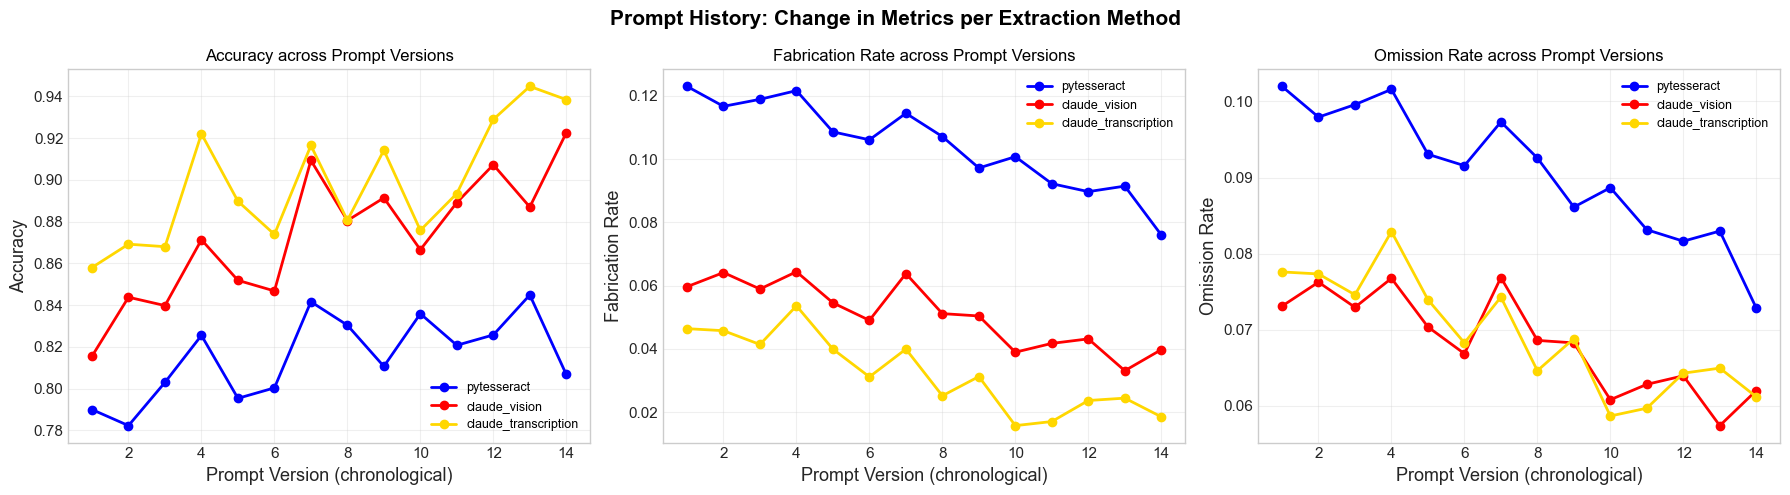

In [17]:
# --- Figure 2: Metric Trends across Prompt Versions (Additive Models style) ---
colors = {"pytesseract": "b", "claude_vision": "r", "claude_transcription": "gold"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

for metric, ax, title in zip(
    ["accuracy", "fabrication_rate", "omission_rate"],
    axes,
    ["Accuracy", "Fabrication Rate", "Omission Rate"],
):
    for method in methods_list:
        subset = df_trajectory[df_trajectory["method"] == method].sort_values("version_order")
        ax.plot(
            subset["version_order"], subset[metric],
            color=colors.get(method, "grey"), marker="o", linewidth=2, label=method
        )
    ax.set_xlabel("Prompt Version (chronological)")
    ax.set_ylabel(title)
    ax.set_title(f"{title} across Prompt Versions")
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Prompt History: Change in Metrics per Extraction Method",
    fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "prompt_history_metric_trends.png", dpi=300, bbox_inches="tight")
plt.show()

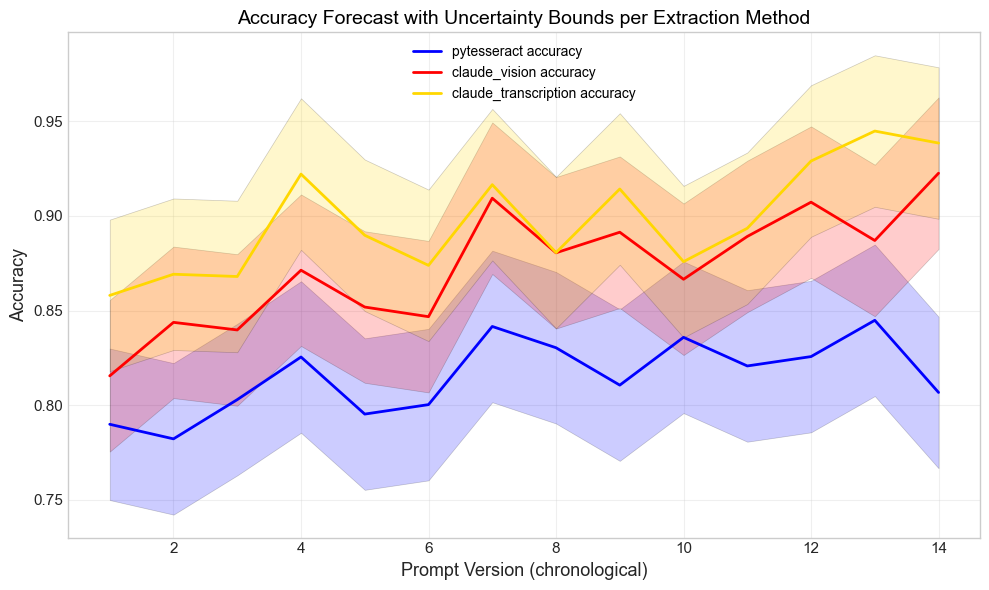

In [18]:
# --- Figure 3: Forecast-style comparison with uncertainty bounds (Additive Models style) ---
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

for method in methods_list:
    subset = df_trajectory[df_trajectory["method"] == method].sort_values("version_order")
    y = subset["accuracy"].values
    x = subset["version_order"].values
    # Simulate uncertainty bounds (in production, use bootstrap CIs)
    upper = np.clip(y + 0.04, 0, 1)
    lower = np.clip(y - 0.04, 0, 1)
    
    color = colors.get(method, "grey")
    ax.plot(x, y, color=color, linewidth=2, label=f"{method} accuracy")
    ax.fill_between(x, upper, lower, alpha=0.2, color=color, edgecolor="k", linewidth=0.5)

ax.set_xlabel("Prompt Version (chronological)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Forecast with Uncertainty Bounds per Extraction Method", fontsize=14)
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_forecast_uncertainty.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# --- Save all comparison outputs ---
df_trajectory.to_csv(OUTPUT_DIR / "prompt_metric_trajectories.csv", index=False)

print("=" * 60)
print("OUTPUTS SAVED")
print("=" * 60)
for f in [
    "extraction_method_comparison.csv",
    "extraction_method_boxplots.png",
    "prompt_history_metric_trends.png",
    "accuracy_forecast_uncertainty.png",
    "prompt_metric_trajectories.csv",
]:
    fpath = OUTPUT_DIR / f
    status = f"{fpath.stat().st_size / 1024:.1f} KB" if fpath.exists() else "PENDING (run cells above)"
    print(f"  {f:50s} {status}")

OUTPUTS SAVED
  extraction_method_comparison.csv                   1358.3 KB
  extraction_method_boxplots.png                     243.4 KB
  prompt_history_metric_trends.png                   498.3 KB
  accuracy_forecast_uncertainty.png                  455.7 KB
  prompt_metric_trajectories.csv                     3.4 KB
